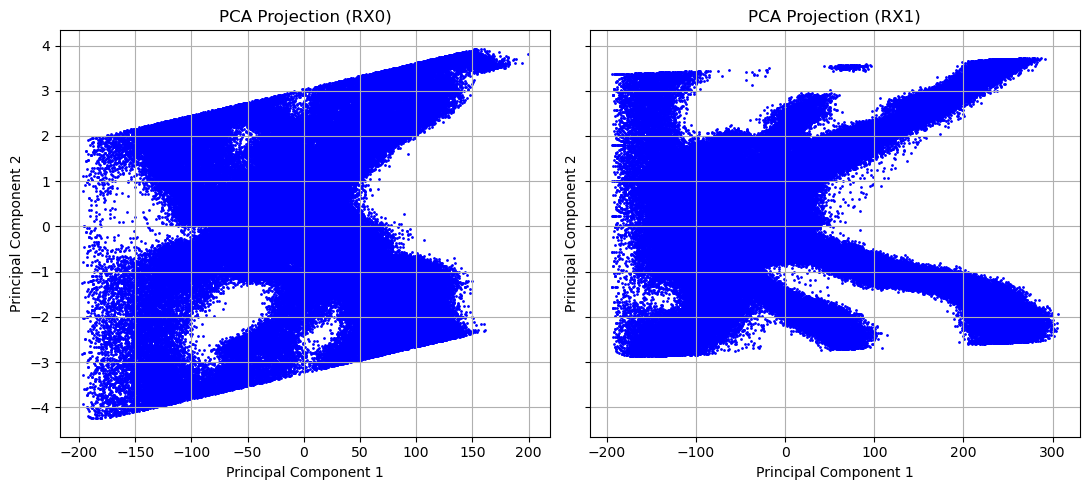

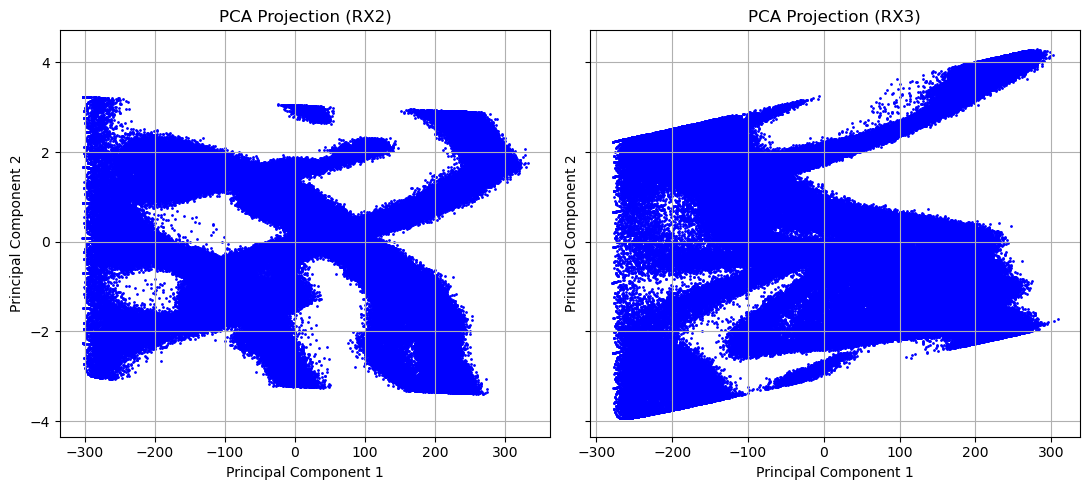

In [13]:
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

def convert_to_data_frame(matlabFilePath, variableName):
    matData = scipy.io.loadmat(matlabFilePath)
    xdata = matData[variableName]

    df = pd.DataFrame(xdata)
    df = df.transpose()
    df.columns = ['RX0', 'RX1', 'RX2', 'RX3']
    return df

def df_polar(df, rx):
    df1 = pd.DataFrame()
    df1['RX'] = df[rx]
    df1['magnitude'] = df[rx].apply(np.abs)
    df1['phase'] = df[rx].apply(np.angle)
    return df1

def polar_data_pca_two(df1, df2, labels=('RX A', 'RX B')):
    fig, axs = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

    for ax, df, label in zip(axs, [df1, df2], labels):
        # PCA on magnitude + phase
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(df[['magnitude', 'phase']])
        df['pc1'] = X_pca[:, 0]
        df['pc2'] = X_pca[:, 1]

        # Scatter plot
        ax.scatter(df['pc1'], df['pc2'], s=1, color='blue')
        ax.set_title(f"PCA Projection ({label})")
        ax.set_xlabel("Principal Component 1")
        ax.set_ylabel("Principal Component 2")
        ax.grid(True)

    plt.tight_layout()
    plt.show()




adc_data = convert_to_data_frame(r'C:\Users\kavin\20250110\_5\adc_data.mat', 'ans')
adc_data_polar_rx0 = df_polar(adc_data, 'RX0')
adc_data_polar_rx1 = df_polar(adc_data, 'RX1')
polar_data_pca_two(adc_data_polar_rx0, adc_data_polar_rx1, labels=('RX0', 'RX1'))
adc_data_polar_rx2 = df_polar(adc_data, 'RX2')
adc_data_polar_rx3 = df_polar(adc_data, 'RX3')
polar_data_pca_two(adc_data_polar_rx2, adc_data_polar_rx3, labels=('RX2', 'RX3'))